## Imports

In [4]:
# Data loading
from datasets import load_dataset

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing 
import re
import nltk

# Suppress minor warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [5]:
# Load the IMDB dataset from Hugging Face
imdb = load_dataset("stanfordnlp/imdb")

# Inspect the structure
print(imdb)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


## Explore Data (EDA)

In [6]:
# Convert train and test splits to pandas DataFrames
train_df = imdb['train'].to_pandas()
test_df = imdb['test'].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (25000, 2)
Test shape: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


Train label distribution:
label
0    12500
1    12500
Name: count, dtype: int64

Test label distribution:
label
0    12500
1    12500
Name: count, dtype: int64


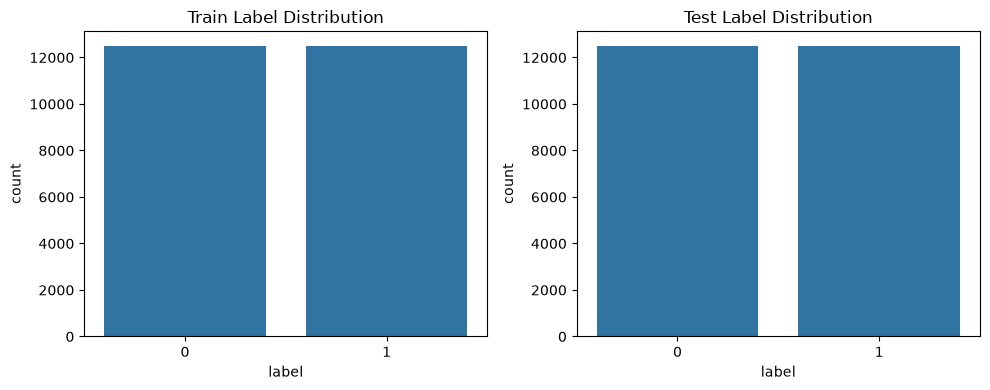

In [7]:
# Check class balance in train and test sets
print("Train label distribution:")
print(train_df['label'].value_counts())

print("\nTest label distribution:")
print(test_df['label'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=train_df, x='label', ax=axes[0])
axes[0].set_title('Train Label Distribution')
sns.countplot(data=test_df, x='label', ax=axes[1])
axes[1].set_title('Test Label Distribution')
plt.tight_layout()
plt.show()

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_count, dtype: float64


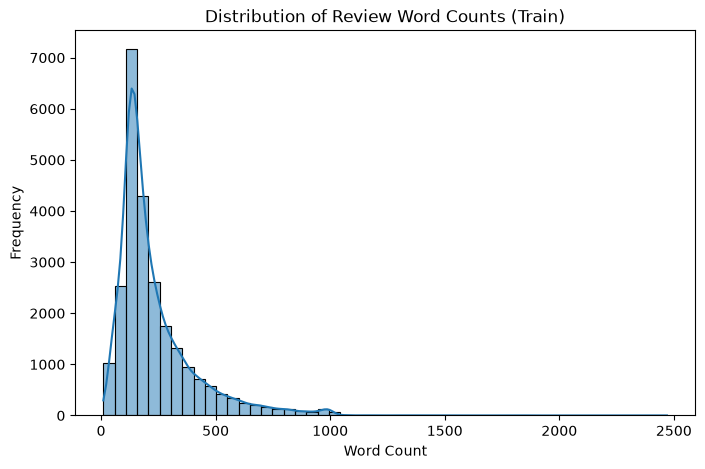

In [22]:
# Calculate text length (word count) for each review
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

print(train_df['word_count'].describe())

# Visualize distribution
plt.figure(figsize=(8, 5))
sns.histplot(train_df['word_count'], bins=50, kde=True)
plt.title('Distribution of Review Word Counts (Train)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

In [8]:
# Look at one negative review (label 0) and one positive review (label 1)
print("=== NEGATIVE REVIEW SAMPLE ===")
print(train_df[train_df['label'] == 0]['text'].iloc[0])

print("\n\n=== POSITIVE REVIEW SAMPLE ===")
print(train_df[train_df['label'] == 1]['text'].iloc[0])

=== NEGATIVE REVIEW SAMPLE ===
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scen

## Preprocessing

In [9]:
def clean_text(text):
    # Remove HTML tags like <br />
    text = re.sub(r'<.*?>', ' ', text)
    
    # Lowercase everything
    text = text.lower()
    
    # Remove punctuation and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test it on the negative sample we looked at earlier
sample = train_df['text'].iloc[0]
print("BEFORE:\n", sample[:300])
print("\nAFTER:\n", clean_text(sample)[:300])

BEFORE:
 I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

AFTER:
 i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by u s customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see 


In [11]:
# Apply cleaning function to all reviews in train and test sets
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

# Confirm it worked
train_df[['text', 'clean_text']].head()

,text,clean_text
0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curious yellow from my video sto...
1,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...
2,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...
3,This film was probably inspired by Godard's Ma...,this film was probably inspired by godard s ma...
4,"Oh, brother...after hearing about this ridicul...",oh brother after hearing about this ridiculous...


## Feature Extraction (TF-IDF)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,   # keep only the top 10,000 most frequent words (by document frequency) as vocabulary
    ngram_range=(1, 2),   # consider both unigrams (single words) and bigrams (two-word phrases)
    min_df=5,             # ignore words that appear in fewer than 5 reviews (too rare, likely noise/typos)
    max_df=0.8            # ignore words that appear in more than 80% of reviews (too common, low signal - like "movie", "film")
)

# Fit on training data and transform both train and test sets
X_train = tfidf.fit_transform(train_df['clean_text'])
X_test = tfidf.transform(test_df['clean_text'])

y_train = train_df['label']
y_test = test_df['label']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (25000, 10000)
X_test shape: (25000, 10000)


## Train Model

In [13]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## Evaluate Model


Accuracy: 0.8938

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89     12500
    Positive       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



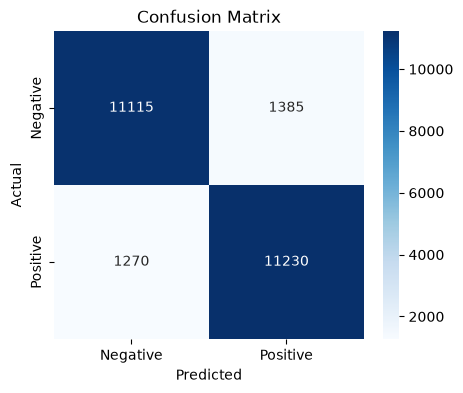

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on test set
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Full classification report (precision, recall, F1 per class)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Compare Models

In [15]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# --- Naive Bayes ---
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)

# --- Linear SVM ---
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

# --- Comparison table ---
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Linear SVM'],
    'Accuracy': [acc, nb_acc, svm_acc]
})

print(results)

                 Model  Accuracy
0  Logistic Regression   0.89380
1          Naive Bayes   0.86168
2           Linear SVM   0.88408


## Load Pre-trained GloVe Embeddings

In [2]:
import gensim.downloader as api

# Download and load pre-trained GloVe embeddings (100-dimensional)
# This downloads ~128MB the first time, then caches it locally
glove_vectors = api.load("glove-wiki-gigaword-100")

print("Vocabulary size:", len(glove_vectors))
print("Vector dimension:", glove_vectors.vector_size)

# Quick sanity check - look at a word's vector and find similar words
print("\nVector for 'good' (first 10 values):", glove_vectors['good'][:10])
print("\nWords most similar to 'good':", glove_vectors.most_similar('good', topn=5))

[==================================================] 100.0% 128.1/128.1MB downloaded
Vocabulary size: 400000
Vector dimension: 100

Vector for 'good' (first 10 values): [-0.030769  0.11993   0.53909  -0.43696  -0.73937  -0.15345   0.081126
 -0.38559  -0.68797  -0.41632 ]

Words most similar to 'good': [('better', 0.893191397190094), ('sure', 0.8314563035964966), ('really', 0.8297762870788574), ('kind', 0.8288268446922302), ('very', 0.8260800242424011)]


## Convert Reviews to Averaged GloVe Vectors

In [16]:
def get_avg_glove_vector(text, glove_vectors, dim=100):
    words = text.split()
    # Only keep words that exist in GloVe's vocabulary
    valid_vectors = [glove_vectors[word] for word in words if word in glove_vectors]
    
    if len(valid_vectors) == 0:
        return np.zeros(dim)  # fallback for reviews with no known words
    
    return np.mean(valid_vectors, axis=0)

# Test on one review first
sample_vector = get_avg_glove_vector(train_df['clean_text'].iloc[0], glove_vectors)
print("Sample vector shape:", sample_vector.shape)
print("First 10 values:", sample_vector[:10])

Sample vector shape: (100,)
First 10 values: [ 0.0260291   0.17053394  0.34607947 -0.15983701 -0.0197869   0.24298455
 -0.1685387   0.13016525 -0.07418208  0.04289039]


In [17]:
# Apply the averaging function to every review in train and test sets
X_train_glove = np.array([get_avg_glove_vector(text, glove_vectors) for text in train_df['clean_text']])
X_test_glove = np.array([get_avg_glove_vector(text, glove_vectors) for text in test_df['clean_text']])

print("X_train_glove shape:", X_train_glove.shape)
print("X_test_glove shape:", X_test_glove.shape)

X_train_glove shape: (25000, 100)
X_test_glove shape: (25000, 100)


## Neural Network (PyTorch)

In [18]:
import torch
import torch.nn as nn

# Define the neural network architecture
class SentimentNN(nn.Module):
    def __init__(self, input_dim=100):
        super(SentimentNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)   # input layer -> hidden layer 1
        self.fc2 = nn.Linear(64, 32)          # hidden layer 1 -> hidden layer 2
        self.fc3 = nn.Linear(32, 1)           # hidden layer 2 -> output
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Instantiate the model
model_nn = SentimentNN(input_dim=100)
print(model_nn)

SentimentNN(
  (fc1): Linear(in_features=100, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


## Prepare Data for Training

In [19]:
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_glove, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)  # shape (N,1) to match model output

X_test_tensor = torch.tensor(X_test_glove, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Wrap into TensorDataset, then DataLoader for batching
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("Number of batches per epoch:", len(train_loader))

X_train_tensor shape: torch.Size([25000, 100])
y_train_tensor shape: torch.Size([25000, 1])
Number of batches per epoch: 391


## Train the Neural Network

In [20]:
import torch.optim as optim

# Loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model_nn.parameters(), lr=0.001)

# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    model_nn.train()  # set model to training mode
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()              # reset gradients from previous batch
        outputs = model_nn(batch_X)        # forward pass
        loss = criterion(outputs, batch_y) # compute loss
        loss.backward()                    # backward pass (compute gradients)
        optimizer.step()                   # update weights
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 0.5824
Epoch 2/10, Loss: 0.4870
Epoch 3/10, Loss: 0.4711
Epoch 4/10, Loss: 0.4627
Epoch 5/10, Loss: 0.4597
Epoch 6/10, Loss: 0.4525
Epoch 7/10, Loss: 0.4506
Epoch 8/10, Loss: 0.4492
Epoch 9/10, Loss: 0.4451
Epoch 10/10, Loss: 0.4468


## Evaluate Neural Network

In [21]:
model_nn.eval()  # set model to evaluation mode

with torch.no_grad():  # disable gradient tracking for inference
    y_pred_nn_probs = model_nn(X_test_tensor)
    y_pred_nn = (y_pred_nn_probs >= 0.5).float()  # convert probabilities to 0/1 predictions

# Convert to numpy for sklearn metrics
y_pred_nn_np = y_pred_nn.numpy().flatten()
y_test_np = y_test_tensor.numpy().flatten()

nn_acc = accuracy_score(y_test_np, y_pred_nn_np)
print(f"Neural Network (GloVe) Accuracy: {nn_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_np, y_pred_nn_np, target_names=['Negative', 'Positive']))

Neural Network (GloVe) Accuracy: 0.7922

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.86      0.80     12500
    Positive       0.84      0.73      0.78     12500

    accuracy                           0.79     25000
   macro avg       0.80      0.79      0.79     25000
weighted avg       0.80      0.79      0.79     25000



##  Compare All Models So Far

In [22]:
# Combine all results so far into one comparison table
final_results = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF)', 'Naive Bayes (TF-IDF)', 'Linear SVM (TF-IDF)', 'Neural Net (GloVe avg)'],
    'Accuracy': [acc, nb_acc, svm_acc, nn_acc]
})

print(final_results.sort_values(by='Accuracy', ascending=False))

                          Model  Accuracy
0  Logistic Regression (TF-IDF)   0.89380
2           Linear SVM (TF-IDF)   0.88408
1          Naive Bayes (TF-IDF)   0.86168
3        Neural Net (GloVe avg)   0.79220
